In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/satyendranathkar/satendra-subset-folder/val_idx.npy
/kaggle/input/datasets/satyendranathkar/satendra-subset-folder/train_idx.npy
/kaggle/input/datasets/satyendranathkar/satendra-subset-folder/test_idx.npy
/kaggle/input/datasets/satyendranathkar/train-test-val-data/test_idx (1).npy
/kaggle/input/datasets/satyendranathkar/train-test-val-data/train_idx (1).npy
/kaggle/input/datasets/satyendranathkar/train-test-val-data/val_idx (1).npy
/kaggle/input/datasets/satyendranathkar/satyendra/val_idx (3).npy
/kaggle/input/datasets/satyendranathkar/satyendra/train_idx (4).npy
/kaggle/input/datasets/satyendranathkar/satyendra/test_idx (3).npy


In [28]:
!git clone https://github.com/kalviny/MSDNet-PyTorch.git
%cd MSDNet-PyTorch

Cloning into 'MSDNet-PyTorch'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 174 (delta 75), reused 170 (delta 75), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 109.83 KiB | 2.44 MiB/s, done.
Resolving deltas: 100% (75/75), done.
/kaggle/working/MSDNet-PyTorch/MSDNet-PyTorch


In [29]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [30]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("FOLDER:", root)
    for f in files:
        print("   ", f)

FOLDER: /kaggle/input
FOLDER: /kaggle/input/datasets
FOLDER: /kaggle/input/datasets/satyendranathkar
FOLDER: /kaggle/input/datasets/satyendranathkar/satendra-subset-folder
    val_idx.npy
    train_idx.npy
    test_idx.npy
FOLDER: /kaggle/input/datasets/satyendranathkar/train-test-val-data
    test_idx (1).npy
    train_idx (1).npy
    val_idx (1).npy
FOLDER: /kaggle/input/datasets/satyendranathkar/satyendra
    val_idx (3).npy
    train_idx (4).npy
    test_idx (3).npy


In [31]:
import numpy as np
import os

SPLIT_PATH = "/kaggle/input/datasets/satyendranathkar/satyendra"

print("Files inside folder:", os.listdir(SPLIT_PATH))

train_idx = np.load(f"{SPLIT_PATH}/train_idx (4).npy")
val_idx   = np.load(f"{SPLIT_PATH}/val_idx (3).npy")
test_idx  = np.load(f"{SPLIT_PATH}/test_idx (3).npy")

print("Loaded split files successfully!")
print("Train subset size:", len(train_idx))
print("Val subset size:", len(val_idx))
print("Test subset size:", len(test_idx))

Files inside folder: ['val_idx (3).npy', 'train_idx (4).npy', 'test_idx (3).npy']
Loaded split files successfully!
Train subset size: 10000
Val subset size: 2000
Test subset size: 2000


In [32]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms

# -----------------------------
# 1. Transforms
# -----------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

# -----------------------------
# 2. Load full datasets
# -----------------------------
train_full = datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train
)

train_full_eval = datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_test
)

test_full = datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test
)

# -----------------------------
# 3. Desired subset sizes
# -----------------------------
SUBSET_TRAIN = 10000
SUBSET_VAL   = 2000
SUBSET_TEST  = 2000

# -----------------------------
# 4. Random but reproducible split
# -----------------------------
np.random.seed(42)

train_indices_all = np.random.permutation(len(train_full))   # 50,000 shuffled indices
test_indices_all  = np.random.permutation(len(test_full))    # 10,000 shuffled indices

# Split official training set into train + val
train_idx = train_indices_all[:SUBSET_TRAIN]
val_idx   = train_indices_all[SUBSET_TRAIN:SUBSET_TRAIN + SUBSET_VAL]

# Take test subset from official test set
test_idx  = test_indices_all[:SUBSET_TEST]

# -----------------------------
# 5. Create subsets
# -----------------------------
train_dataset = Subset(train_full, train_idx)         # augmented
val_dataset   = Subset(train_full_eval, val_idx)      # clean
test_dataset  = Subset(test_full, test_idx)           # clean

# -----------------------------
# 6. DataLoaders
# -----------------------------
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# -----------------------------
# 7. Check sizes
# -----------------------------
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))



100%|██████████| 169M/169M [00:01<00:00, 93.1MB/s] 


Train samples: 10000
Validation samples: 2000
Test samples: 2000


In [33]:
sys.path.append(os.getcwd())
from models.msdnet import MSDNet

In [34]:
class Args:
    data = 'cifar100'
    nBlocks = 3
    base = 4
    step = 2
    stepmode = 'even'
    growthRate = 12
    nChannels = 32
    

    grFactor = [1, 2, 4]
    bnFactor = [1, 2, 4]

    bottleneck = True
    reduction = 0.5
    use_valid = False
    data_root = './data'
    nScales = 3
    prune = 'max'

In [35]:
args = Args()
model = MSDNet(args).to(device)

print("✅ Model created successfully!")

building network of steps: 
[4, 2, 2] 8
 ********************** Block 1  **********************
|		inScales 3 outScales 3 inChannels 32 outChannels 12		|

|		inScales 3 outScales 3 inChannels 44 outChannels 12		|

|		inScales 3 outScales 3 inChannels 56 outChannels 12		|

|		inScales 3 outScales 2 inChannels 68 outChannels 12		|
|		Transition layer inserted! (max), inChannels 80, outChannels 40	|

 ********************** Block 2  **********************
|		inScales 2 outScales 2 inChannels 40 outChannels 12		|

|		inScales 2 outScales 2 inChannels 52 outChannels 12		|

 ********************** Block 3  **********************
|		inScales 2 outScales 1 inChannels 64 outChannels 12		|
|		Transition layer inserted! (max), inChannels 76, outChannels 38	|

|		inScales 1 outScales 1 inChannels 38 outChannels 12		|

✅ Model created successfully!


In [36]:
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)

print("Output type:", type(outputs))
print("Number of exits:", len(outputs))
for i, out in enumerate(outputs):
    print(f"Exit {i+1} shape:", out.shape)

Output type: <class 'list'>
Number of exits: 3
Exit 1 shape: torch.Size([64, 100])
Exit 2 shape: torch.Size([64, 100])
Exit 3 shape: torch.Size([64, 100])


In [37]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[20, 30],
    gamma=0.1
)

EPOCHS = 40

In [38]:
def train_one_epoch(loader):
    model.train()
    running_loss = 0.0
    correct = None
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if correct is None:
            correct = [0] * len(outputs)

        # equal weighting for official baseline
        loss = 0
        for out in outputs:
            loss += criterion(out, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        for i, out in enumerate(outputs):
            preds = out.argmax(dim=1)
            correct[i] += (preds == labels).sum().item()

        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accs = [c / total for c in correct]
    return avg_loss, accs

In [39]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    running_loss = 0.0
    correct = None
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        if correct is None:
            correct = [0] * len(outputs)

        loss = 0
        for out in outputs:
            loss += criterion(out, labels)

        running_loss += loss.item()

        for i, out in enumerate(outputs):
            preds = out.argmax(dim=1)
            correct[i] += (preds == labels).sum().item()

        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accs = [c / total for c in correct]
    return avg_loss, accs

In [40]:
train_losses, val_losses = [], []
train_exit_accs, val_exit_accs = [], []

best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_accs = train_one_epoch(train_loader)
    val_loss, val_accs = evaluate(val_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_exit_accs.append(train_accs)
    val_exit_accs.append(val_accs)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss {train_loss:.4f} | "
          f"Train Accs {train_accs} | "
          f"Val Loss {val_loss:.4f} | "
          f"Val Accs {val_accs}")

    # save best based on final exit
    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), "/kaggle/working/official_msdnet_best.pth")
        print("✅ Best official model saved!")

Epoch 1/40 | Train Loss 12.6830 | Train Accs [0.0534, 0.0541, 0.0514] | Val Loss 12.0138 | Val Accs [0.0825, 0.078, 0.0785]
✅ Best official model saved!
Epoch 2/40 | Train Loss 11.5673 | Train Accs [0.0927, 0.0958, 0.0928] | Val Loss 11.6328 | Val Accs [0.1135, 0.1205, 0.1115]
✅ Best official model saved!
Epoch 3/40 | Train Loss 10.9716 | Train Accs [0.1234, 0.1266, 0.1223] | Val Loss 10.9368 | Val Accs [0.142, 0.1545, 0.147]
✅ Best official model saved!
Epoch 4/40 | Train Loss 10.4667 | Train Accs [0.1564, 0.1597, 0.1546] | Val Loss 10.5851 | Val Accs [0.159, 0.165, 0.167]
✅ Best official model saved!
Epoch 5/40 | Train Loss 10.0179 | Train Accs [0.1776, 0.1823, 0.1804] | Val Loss 10.2388 | Val Accs [0.1915, 0.189, 0.1835]
✅ Best official model saved!
Epoch 6/40 | Train Loss 9.5839 | Train Accs [0.2044, 0.2093, 0.2102] | Val Loss 9.7795 | Val Accs [0.1975, 0.216, 0.215]
✅ Best official model saved!
Epoch 7/40 | Train Loss 9.1569 | Train Accs [0.2322, 0.2409, 0.2382] | Val Loss 9.2643 

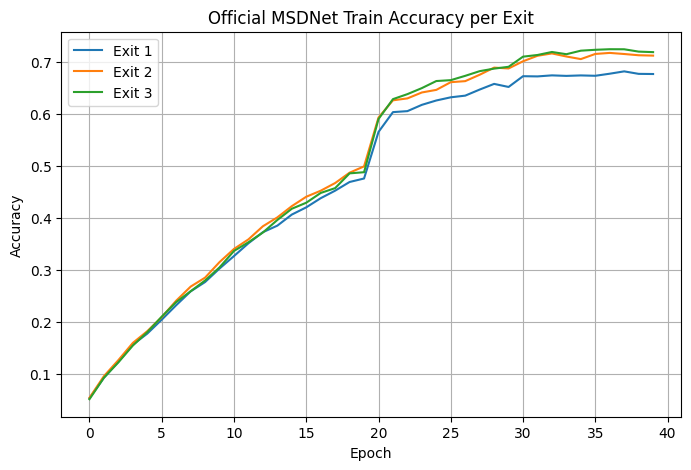

In [41]:
train_exit_accs_np = np.array(train_exit_accs)

plt.figure(figsize=(8,5))
for i in range(train_exit_accs_np.shape[1]):
    plt.plot(train_exit_accs_np[:, i], label=f'Exit {i+1}')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Official MSDNet Train Accuracy per Exit")
plt.legend()
plt.grid(True)
plt.show()

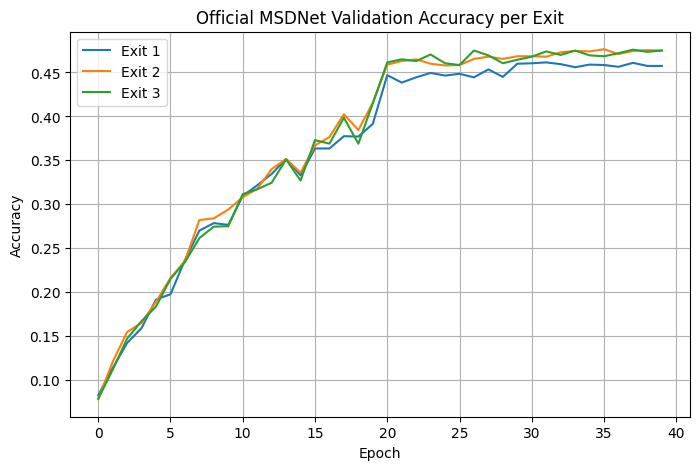

In [42]:
val_exit_accs_np = np.array(val_exit_accs)

plt.figure(figsize=(8,5))
for i in range(val_exit_accs_np.shape[1]):
    plt.plot(val_exit_accs_np[:, i], label=f'Exit {i+1}')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Official MSDNet Validation Accuracy per Exit")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
model.load_state_dict(torch.load("/kaggle/working/official_msdnet_best.pth", map_location=device))

test_loss, test_accs = evaluate(test_loader)

print("===== OFFICIAL MSDNET TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
for i, acc in enumerate(test_accs):
    print(f"Exit {i+1} Accuracy: {acc*100:.2f}%")

===== OFFICIAL MSDNET TEST RESULTS =====
Test Loss: 6.9893
Exit 1 Accuracy: 44.30%
Exit 2 Accuracy: 44.95%
Exit 3 Accuracy: 45.10%


In [45]:
!pip install thop

In [46]:
import torch
import torch.nn as nn

class OfficialEarlyExitWrapper(nn.Module):
    def __init__(self, model, exit_idx):
        super().__init__()
        self.model = model
        self.exit_idx = exit_idx

    def forward(self, x):
        res = x

        # Run only up to required exit
        for i in range(self.exit_idx + 1):
            res = self.model.blocks[i](res)

        # Apply only corresponding classifier
        out = self.model.classifier[self.exit_idx](res)
        return out

In [47]:
from thop import profile

dummy_input = torch.randn(1, 3, 32, 32).to(device)

official_flops_list = []
official_params_list = []


num_exits = len(test_accs)

for i in range(num_exits):
    wrapped_model = OfficialEarlyExitWrapper(model, i).to(device)
    flops, params = profile(wrapped_model, inputs=(dummy_input,), verbose=False)
    official_flops_list.append(flops)
    official_params_list.append(params)

for i, fl in enumerate(official_flops_list):
    print(f"Official Exit {i+1} FLOPs: {fl/1e6:.2f} MFLOPs | Params: {official_params_list[i]/1e6:.2f} M")

Official Exit 1 FLOPs: 54.11 MFLOPs | Params: 0.76 M
Official Exit 2 FLOPs: 72.28 MFLOPs | Params: 1.01 M
Official Exit 3 FLOPs: 85.20 MFLOPs | Params: 1.14 M


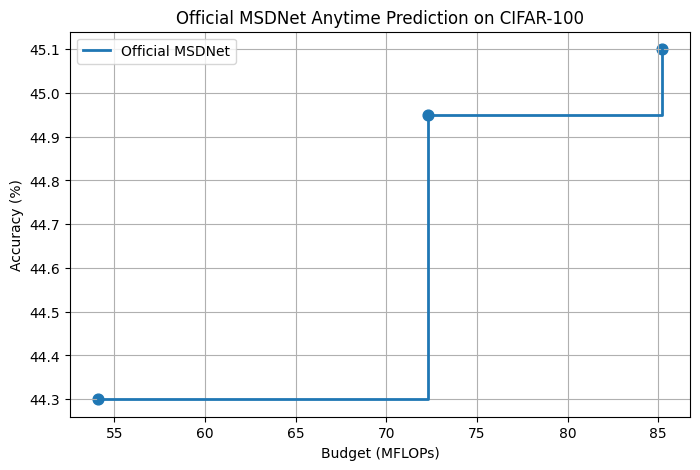

In [48]:
official_budgets_anytime = [f / 1e6 for f in official_flops_list]
official_accs_anytime = [acc * 100 for acc in test_accs]

plt.figure(figsize=(8,5))
plt.step(official_budgets_anytime, official_accs_anytime, where='post', linewidth=2, label='Official MSDNet')
plt.scatter(official_budgets_anytime, official_accs_anytime, s=60)

plt.xlabel("Budget (MFLOPs)")
plt.ylabel("Accuracy (%)")
plt.title("Official MSDNet Anytime Prediction on CIFAR-100")
plt.grid(True)
plt.legend()
plt.show()

In [49]:
@torch.no_grad()
def budgeted_evaluate(model, loader, thresholds, flops_list):
    model.eval()
    correct = 0
    total = 0
    total_flops = 0

    exit_counts = [0] * len(thresholds)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        for i in range(images.size(0)):
            exited = False

            for exit_idx, threshold in enumerate(thresholds):
                probs = F.softmax(outputs[exit_idx][i], dim=0)
                conf, pred = probs.max(dim=0)

                if conf.item() >= threshold:
                    if pred.item() == labels[i].item():
                        correct += 1
                    total += 1
                    total_flops += flops_list[exit_idx]
                    exit_counts[exit_idx] += 1
                    exited = True
                    break

            if not exited:
                pred = outputs[-1][i].argmax().item()
                if pred == labels[i].item():
                    correct += 1
                total += 1
                total_flops += flops_list[-1]
                exit_counts[-1] += 1

    avg_flops = total_flops / total
    acc = correct / total

    return avg_flops / 1e6, acc * 100, exit_counts

In [50]:
threshold_settings = [
    [0.999, 0.999, 0.0],
    [0.995, 0.995, 0.0],
    [0.990, 0.990, 0.0],
    [0.970, 0.970, 0.0],
    [0.950, 0.950, 0.0],
    [0.900, 0.900, 0.0],
    [0.850, 0.850, 0.0],
    [0.800, 0.800, 0.0],
    [0.700, 0.700, 0.0],
    [0.600, 0.600, 0.0],
    [0.500, 0.500, 0.0],
]
budgets_batch, accs_batch = [], []

for th in threshold_settings:
    avg_flops, acc, exit_counts = budgeted_evaluate(model, test_loader, th, official_flops_list)

    budgets_batch.append(avg_flops)
    accs_batch.append(acc)

    total_samples = sum(exit_counts)
    e1 = 100 * exit_counts[0] / total_samples
    e2 = 100 * exit_counts[1] / total_samples
    e3 = 100 * exit_counts[2] / total_samples

    print(f"Thresholds {th}")
    print(f"  Avg Budget: {avg_flops:.2f} MFLOPs | Accuracy: {acc:.2f}%")
    print(f"  Exit 1: {exit_counts[0]} ({e1:.2f}%)")
    print(f"  Exit 2: {exit_counts[1]} ({e2:.2f}%)")
    print(f"  Exit 3: {exit_counts[2]} ({e3:.2f}%)")
    print("-"*50)

Thresholds [0.999, 0.999, 0.0]
  Avg Budget: 84.49 MFLOPs | Accuracy: 45.10%
  Exit 1: 36 (1.80%)
  Exit 2: 23 (1.15%)
  Exit 3: 1941 (97.05%)
--------------------------------------------------
Thresholds [0.995, 0.995, 0.0]
  Avg Budget: 83.63 MFLOPs | Accuracy: 45.10%
  Exit 1: 81 (4.05%)
  Exit 2: 47 (2.35%)
  Exit 3: 1872 (93.60%)
--------------------------------------------------
Thresholds [0.99, 0.99, 0.0]
  Avg Budget: 82.90 MFLOPs | Accuracy: 45.15%
  Exit 1: 120 (6.00%)
  Exit 2: 67 (3.35%)
  Exit 3: 1813 (90.65%)
--------------------------------------------------
Thresholds [0.97, 0.97, 0.0]
  Avg Budget: 81.34 MFLOPs | Accuracy: 45.10%
  Exit 1: 218 (10.90%)
  Exit 2: 73 (3.65%)
  Exit 3: 1709 (85.45%)
--------------------------------------------------
Thresholds [0.95, 0.95, 0.0]
  Avg Budget: 80.33 MFLOPs | Accuracy: 45.15%
  Exit 1: 272 (13.60%)
  Exit 2: 99 (4.95%)
  Exit 3: 1629 (81.45%)
--------------------------------------------------
Thresholds [0.9, 0.9, 0.0]
  Av

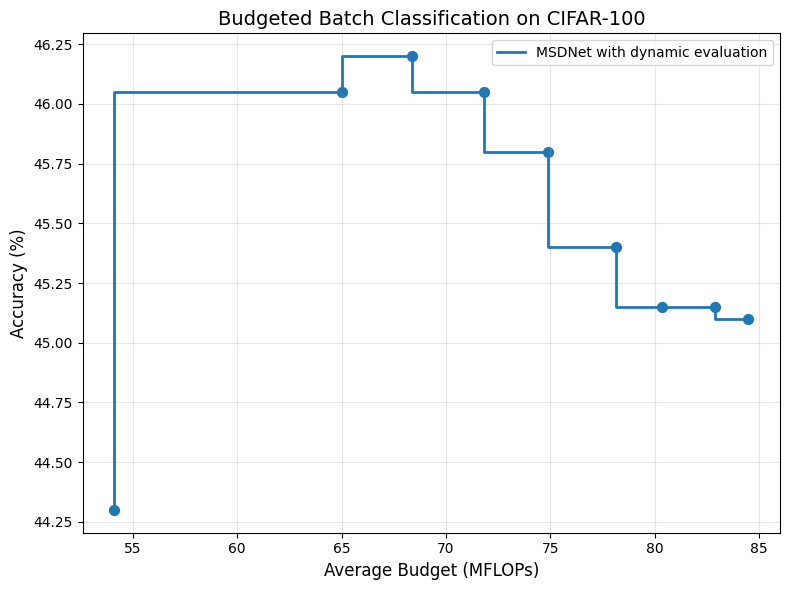

In [53]:
# budgets_batch is already in MFLOPs (returned directly from budgeted_evaluate)
# BUG FIX: removed the erroneous / 1e6 that was shrinking the x-axis by 1e6

plt.figure(figsize=(8, 6))
plt.step(budgets_batch, accs_batch, where='post', linewidth=2, label="MSDNet with dynamic evaluation")
plt.scatter(budgets_batch, accs_batch, s=50)

plt.title("Budgeted Batch Classification on CIFAR-100", fontsize=14)
plt.xlabel("Average Budget (MFLOPs)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
